# Primary Experiments

Running on: cuda
Preparing Data...
Loading Models (ResNet18 & ViT-B-16)...
Dimensions -> ResNet: 512, ViT: 768

Starting Training USAE (10 Epochs)...


Epoch 10/10: 100%|██████████| 40/40 [01:07<00:00,  1.68s/it, loss=0.382]


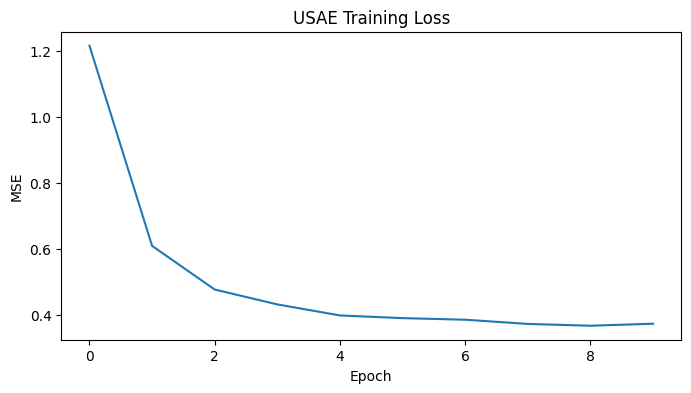


Calculating Comprehensive Metrics...


Evaluating: 100%|██████████| 8/8 [00:13<00:00,  1.70s/it]


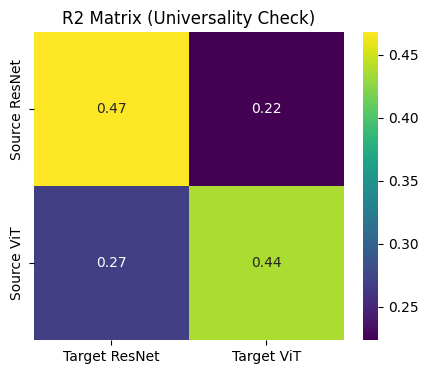

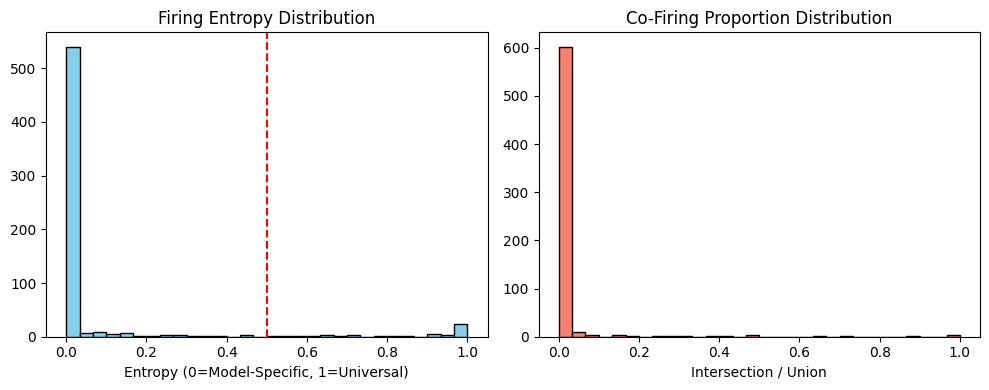


--- Visualizing High Entropy (Universal) Features ---
Feature  | Entropy  | ResNet %   | ViT %     
496      | 1.0000   | 50.00%     | 50.00%
1196     | 1.0000   | 50.00%     | 50.00%
1301     | 1.0000   | 50.00%     | 50.00%


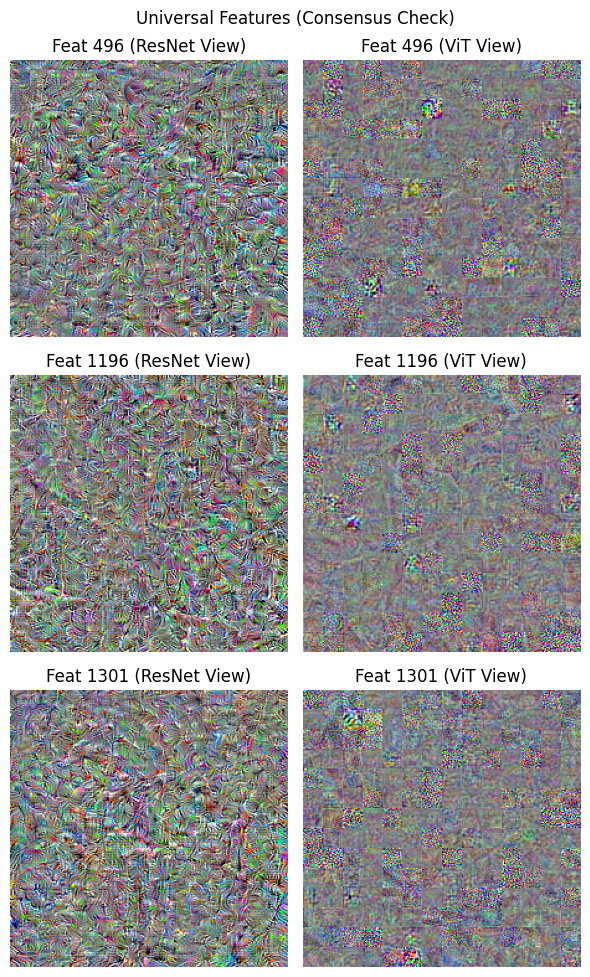


--- Visualizing Low Entropy (Model-Specific) Features ---


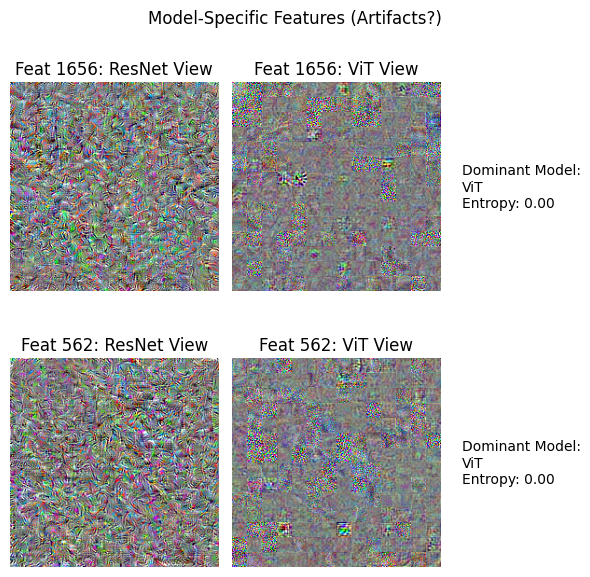


=== Supplementary Analysis ===
Feature Splitting Indicator (Avg Jaccard): 0.0193
-> Low Jaccard (<0.3) implies 'Feature Splitting' or 'Polysemantic Mismatch'.

Running Independent SAE Baseline (ResNet Only)...
Independent SAE R2 (ResNet): 0.5820
USAE R2 (ResNet -> ResNet): 0.4678
Alignment Tax: 0.1142
-> We paid a 11.4% performance penalty to achieve universality.


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import r2_score
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim


# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

CONFIG = {
    'batch_size': 128,
    'lr': 1e-3,
    'epochs': 10,          # Increased to 10 as requested
    'dict_size': 2048,     # Shared Feature Space (m)
    'k': 32,               # TopK sparsity
    'image_size': 224      # Standard ImageNet size
}

# ==========================================
# 2. DATA & MODEL LOADING
# ==========================================

# Standard transform for ImageNet-trained models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Preparing Data...")
# We use CIFAR-10. Note: Upsampling to 224 is slow but necessary for standard ViT/ResNet
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# Subset for reasonable training time in a demo
train_subset = torch.utils.data.Subset(train_set, list(range(0, 5000)))
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=CONFIG['batch_size'], shuffle=True)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_subset = torch.utils.data.Subset(test_set, list(range(0, 1000)))
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=CONFIG['batch_size'], shuffle=False)

print("Loading Models (ResNet18 & ViT-B-16)...")
model_A = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(DEVICE)
model_B = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT).to(DEVICE)
model_A.eval()
model_B.eval()

# --- CORRECTED HOOK FUNCTION ---
activations = {}
def get_activation(name):
    def hook(model, input, output):
        # Handle CNNs: (Batch, Channels, Height, Width) -> 4D Tensor
        if len(output.shape) == 4:
            activations[name] = output.mean(dim=[2, 3])

        # Handle ViT: (Batch, Sequence, Dimension) -> 3D Tensor
        elif len(output.shape) == 3:
            # Take the CLS token (index 0) which represents the whole image
            activations[name] = output[:, 0, :]

        # Handle already flattened inputs
        else:
            activations[name] = output
    return hook

# Register hooks
model_A.layer4.register_forward_hook(get_activation('Model_A'))
model_B.encoder.layers.encoder_layer_11.register_forward_hook(get_activation('Model_B'))

# Dummy pass to get dimensions
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    model_A(dummy); model_B(dummy)
    dim_A = activations['Model_A'].shape[1]
    dim_B = activations['Model_B'].shape[1]

print(f"Dimensions -> ResNet: {dim_A}, ViT: {dim_B}")

# ==========================================
# 3. USAE ARCHITECTURE
# ==========================================
class USAE(nn.Module):
    def __init__(self, input_dims, dict_size, k=32):
        super().__init__()
        self.num_models = len(input_dims)
        self.k = k
        self.dict_size = dict_size

        # Encoders & Decoders
        self.encoders = nn.ModuleList([nn.Linear(d, dict_size) for d in input_dims])
        self.b_pre = nn.ParameterList([nn.Parameter(torch.zeros(d)) for d in input_dims])
        self.decoders = nn.ModuleList([nn.Linear(dict_size, d) for d in input_dims])
        self.b_dec = nn.ParameterList([nn.Parameter(torch.zeros(d)) for d in input_dims])

        # Init
        for m in self.encoders: nn.init.kaiming_uniform_(m.weight)
        for m in self.decoders: nn.init.kaiming_uniform_(m.weight)

    def encode(self, x, model_idx):
        x_centered = x - self.b_pre[model_idx]
        pre_act = self.encoders[model_idx](x_centered)
        # TopK
        topk_vals, topk_inds = torch.topk(pre_act, self.k, dim=1)
        z = torch.zeros_like(pre_act)
        z.scatter_(1, topk_inds, topk_vals)
        return z

    def decode(self, z, target_idx):
        return self.decoders[target_idx](z) + self.b_dec[target_idx]

    def forward(self, x, source_idx):
        z = self.encode(x, source_idx)
        recons = [self.decode(z, j) for j in range(self.num_models)]
        return recons, z

# ==========================================
# 4. TRAINING LOOP
# ==========================================
usae = USAE([dim_A, dim_B], CONFIG['dict_size'], k=CONFIG['k']).to(DEVICE)
optimizer = optim.Adam(usae.parameters(), lr=CONFIG['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

train_losses = []
print("\nStarting Training USAE (10 Epochs)...")

for epoch in range(CONFIG['epochs']):
    epoch_loss = 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")

    for images, _ in progress:
        images = images.to(DEVICE)

        # Get Ground Truths
        with torch.no_grad():
            model_A(images); act_A = activations['Model_A'].detach()
            model_B(images); act_B = activations['Model_B'].detach()
            gts = [act_A, act_B]

        # Random Source
        source_idx = np.random.randint(0, 2)

        # Forward & Loss
        recons, _ = usae(gts[source_idx], source_idx)
        loss = sum([nn.MSELoss()(recons[j], gts[j]) for j in range(2)])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix({'loss': loss.item()})

    scheduler.step()
    train_losses.append(epoch_loss / len(train_loader))

# Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("USAE Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.show()

# ==========================================
# 5. METRICS: R2, ENTROPY, CO-FIRING
# ==========================================
print("\nCalculating Comprehensive Metrics...")

# Storage
feat_acts_sum = np.zeros((CONFIG['dict_size'], 2))
r2_matrix = np.zeros((2, 2))
r2_steps = 0
co_fire_counts = np.zeros((CONFIG['dict_size']))
union_counts = np.zeros((CONFIG['dict_size']))

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Evaluating"):
        images = images.to(DEVICE)
        model_A(images); act_A = activations['Model_A']
        model_B(images); act_B = activations['Model_B']
        gts = [act_A, act_B]

        # 1. R2 & Entropy Stats
        for i in range(2):
            recons, z = usae(gts[i], i)
            # Track activations
            mask = (z > 0).float().cpu().numpy()
            feat_acts_sum[:, i] += mask.sum(axis=0)

            for j in range(2):
                score = r2_score(gts[j].cpu().numpy(), recons[j].cpu().numpy(), multioutput='variance_weighted')
                r2_matrix[i, j] += score

        r2_steps += 1

        # 2. Co-Firing (Instance Level)
        _, z_a = usae(act_A, 0)
        _, z_b = usae(act_B, 1)
        mask_a = (z_a > 0).cpu().numpy()
        mask_b = (z_b > 0).cpu().numpy()

        co_fire_counts += (mask_a & mask_b).sum(axis=0)
        union_counts += (mask_a | mask_b).sum(axis=0)

r2_matrix /= r2_steps
total_acts = feat_acts_sum.sum(axis=1, keepdims=True) + 1e-8
probs = feat_acts_sum / total_acts
probs = np.clip(probs, 1e-8, 1.0)
entropy = -np.sum(probs * np.log(probs), axis=1) / np.log(2)

# Co-Firing Proportions
active_mask = feat_acts_sum.sum(axis=1) > 0
co_firing_prop = co_fire_counts / (union_counts + 1e-8)
active_cofire = co_firing_prop[active_mask]

# --- PLOTS ---

# 1. R2 Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(r2_matrix, annot=True, cmap='viridis',
            xticklabels=['Target ResNet', 'Target ViT'],
            yticklabels=['Source ResNet', 'Source ViT'])
plt.title("R2 Matrix (Universality Check)")
plt.show()

# 2. Entropy Histogram
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(entropy[active_mask], bins=30, color='skyblue', edgecolor='black')
plt.title("Firing Entropy Distribution")
plt.xlabel("Entropy (0=Model-Specific, 1=Universal)")
plt.axvline(0.5, color='r', linestyle='--')

# 3. Co-Firing Histogram (New Request)
plt.subplot(1, 2, 2)
plt.hist(active_cofire, bins=30, color='salmon', edgecolor='black')
plt.title("Co-Firing Proportion Distribution")
plt.xlabel("Intersection / Union")
plt.tight_layout()
plt.show()

# ==========================================
# 6. VISUALIZATION: ROBUST CAM
# ==========================================

def optimize_feature_robust(model_idx, feature_idx, steps=200, lr=0.05, decay=1e-4):
    img = (torch.randn(1, 3, 224, 224) * 0.1).to(DEVICE).requires_grad_(True)
    optimizer = optim.SGD([img], lr=lr, momentum=0.9, weight_decay=decay)

    for _ in range(steps):
        optimizer.zero_grad()
        if model_idx == 0: model_A(img); act = activations['Model_A']
        else: model_B(img); act = activations['Model_B']

        z_pre = usae.encoders[model_idx](act - usae.b_pre[model_idx])
        loss = -z_pre[0, feature_idx]
        loss.backward()

        # Gradient Normalization
        if img.grad is not None:
            img.grad /= (torch.std(img.grad) + 1e-8)
        optimizer.step()
    return img.detach().cpu()

def robust_plot(tensor):
    img = tensor.squeeze().permute(1, 2, 0).numpy()
    vmin, vmax = np.percentile(img, 1), np.percentile(img, 99)
    img = np.clip(img, vmin, vmax)
    img = (img - vmin) / (vmax - vmin)
    return img

# --- A. HIGH ENTROPY (UNIVERSAL) ---
print("\n--- Visualizing High Entropy (Universal) Features ---")
# Get top 3 indices
sorted_indices = np.argsort(entropy)
high_indices = sorted_indices[-3:] # Top 3 highest entropy

# Print Table
print(f"{'Feature':<8} | {'Entropy':<8} | {'ResNet %':<10} | {'ViT %':<10}")
for idx in high_indices:
    tot = feat_acts_sum[idx].sum()
    p_a = feat_acts_sum[idx, 0]/tot if tot>0 else 0
    p_b = feat_acts_sum[idx, 1]/tot if tot>0 else 0
    print(f"{idx:<8} | {entropy[idx]:.4f}   | {p_a:.2%}     | {p_b:.2%}")

fig, axes = plt.subplots(3, 2, figsize=(6, 10))
plt.suptitle("Universal Features (Consensus Check)")
for i, idx in enumerate(high_indices):
    axes[i, 0].imshow(robust_plot(optimize_feature_robust(0, idx)))
    axes[i, 0].set_title(f"Feat {idx} (ResNet View)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(robust_plot(optimize_feature_robust(1, idx)))
    axes[i, 1].set_title(f"Feat {idx} (ViT View)")
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

# --- B. LOW ENTROPY (MODEL-SPECIFIC) ---
print("\n--- Visualizing Low Entropy (Model-Specific) Features ---")
# Get bottom 2 indices (that are active)
active_indices = np.where(active_mask)[0]
low_indices = sorted(active_indices, key=lambda x: entropy[x])[:2]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
plt.suptitle("Model-Specific Features (Artifacts?)")
for i, idx in enumerate(low_indices):
    # Print ownership
    counts = feat_acts_sum[idx]
    owner = "ResNet" if counts[0] > counts[1] else "ViT"

    axes[i, 0].imshow(robust_plot(optimize_feature_robust(0, idx)))
    axes[i, 0].set_title(f"Feat {idx}: ResNet View")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(robust_plot(optimize_feature_robust(1, idx)))
    axes[i, 1].set_title(f"Feat {idx}: ViT View")
    axes[i, 1].axis('off')

    # Add annotation
    axes[i, 1].text(1.1, 0.5, f"Dominant Model:\n{owner}\nEntropy: {entropy[idx]:.2f}",
                    transform=axes[i, 1].transAxes, verticalalignment='center')

plt.tight_layout()
plt.show()

# ==========================================
# 7. SUPPLEMENTARY: ALIGNMENT TAX & SPLITTING
# ==========================================
print("\n=== Supplementary Analysis ===")

# 1. Feature Splitting (Jaccard)
# If A splits into B1, B2, overlap is messy. Low Jaccard indicates splitting or mismatch.
avg_jaccard = np.mean(active_cofire)
print(f"Feature Splitting Indicator (Avg Jaccard): {avg_jaccard:.4f}")
print("-> Low Jaccard (<0.3) implies 'Feature Splitting' or 'Polysemantic Mismatch'.")

# 2. Alignment Tax (Independent SAE Comparison)
print("\nRunning Independent SAE Baseline (ResNet Only)...")
indep_sae = USAE([dim_A], CONFIG['dict_size'], k=CONFIG['k']).to(DEVICE)
opt_indep = optim.Adam(indep_sae.parameters(), lr=CONFIG['lr'])

# Quick Train (Same epochs)
for epoch in range(CONFIG['epochs']):
    for images, _ in train_loader:
        images = images.to(DEVICE)
        with torch.no_grad():
            model_A(images); act_A = activations['Model_A'].detach()
        recons, _ = indep_sae(act_A, 0)
        loss = nn.MSELoss()(recons[0], act_A)
        opt_indep.zero_grad(); loss.backward(); opt_indep.step()

# Evaluate Independent SAE
indep_r2 = 0; steps = 0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        model_A(images); act_A = activations['Model_A']
        recons, _ = indep_sae(act_A, 0)
        indep_r2 += r2_score(act_A.cpu().numpy(), recons[0].cpu().numpy(), multioutput='variance_weighted')
        steps += 1
indep_r2 /= steps

usae_r2_aa = r2_matrix[0, 0]
tax = indep_r2 - usae_r2_aa

print(f"Independent SAE R2 (ResNet): {indep_r2:.4f}")
print(f"USAE R2 (ResNet -> ResNet): {usae_r2_aa:.4f}")
print(f"Alignment Tax: {tax:.4f}")
if tax > 0:
    print(f"-> We paid a {tax*100:.1f}% performance penalty to achieve universality.")
else:
    print("-> Surprisingly, USAE outperformed Independent SAE (Regularization effect?).")

# SUPPLEMENTARY EXPERIMENTS


=== Exp 8: Semantic Retrieval in Shared Space ===
Building Z-Space Index...


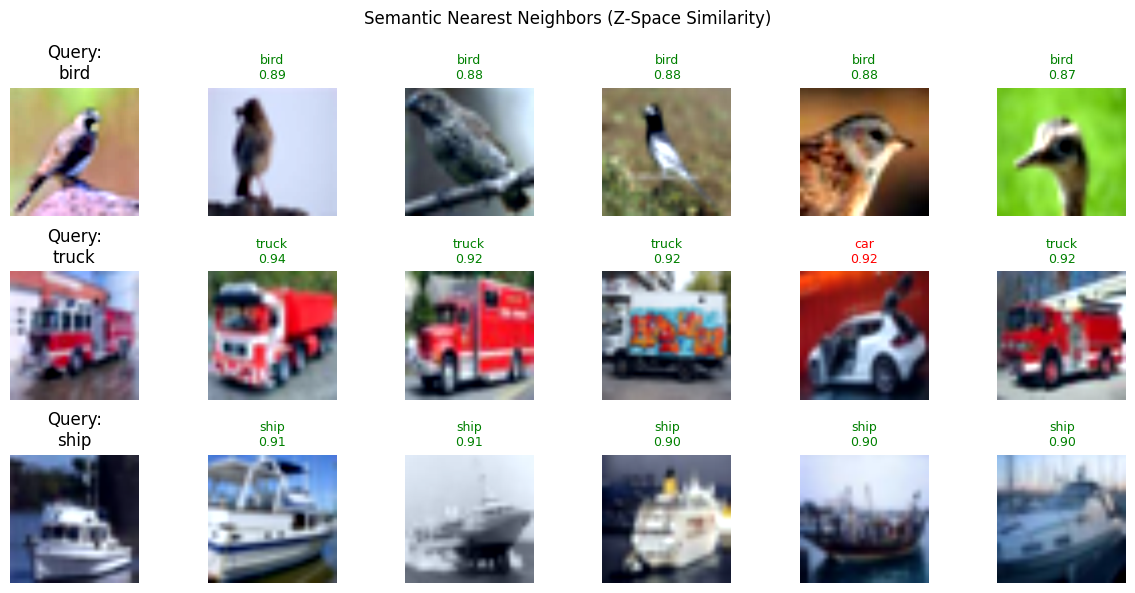


=== Exp 9: Class-Stratified Universality Breakdown ===


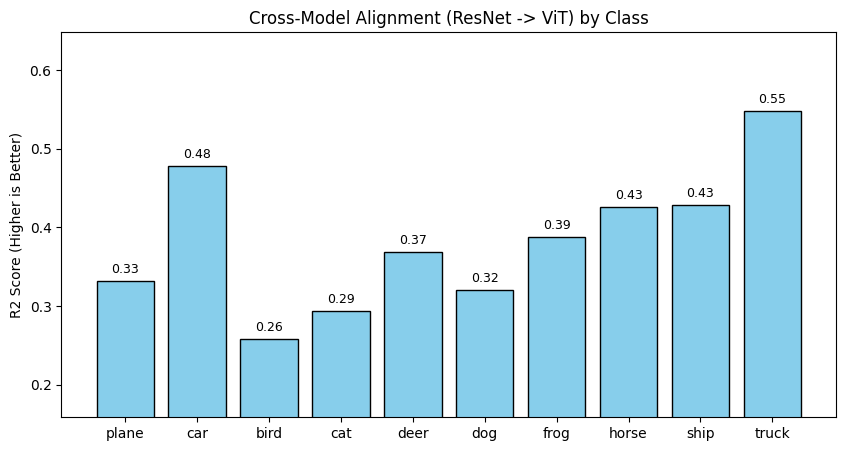

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 8. SUPPLEMENTARY: SEMANTIC RETRIEVAL
# ==========================================
print("\n=== Exp 8: Semantic Retrieval in Shared Space ===")

# 1. Collect all Test Z-vectors and Labels
all_z = []
all_labels = []
all_images = []

print("Building Z-Space Index...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        # We will use Model A (ResNet) to encode the "Database"
        model_A(images)
        act_A = activations['Model_A']
        _, z = usae(act_A, 0) # Encode via ResNet

        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())
        # Store a few images for visualization (cpu)
        all_images.append(images.cpu())

all_z = np.vstack(all_z)
all_labels = np.concatenate(all_labels)
all_images = torch.cat(all_images)

# CIFAR Classes
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Perform Search
# We pick 3 random "Query" images
query_indices = np.random.choice(len(all_z), 3, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
plt.suptitle("Semantic Nearest Neighbors (Z-Space Similarity)")

for i, query_idx in enumerate(query_indices):
    query_vec = all_z[query_idx].reshape(1, -1)
    query_label = classes[all_labels[query_idx]]

    # Compute Cosine Sim against ALL other vectors
    sims = cosine_similarity(query_vec, all_z).flatten()

    # Get Top 5 (excluding self)
    # argsort gives ascending, so we take from end. We skip the last one (self)
    top_indices = np.argsort(sims)[-6:-1][::-1]

    # Plot Query
    ax_q = axes[i, 0]
    ax_q.imshow(robust_plot(all_images[query_idx]))
    ax_q.set_title(f"Query:\n{query_label}")
    ax_q.axis('off')

    # Plot Neighbors
    for j, neighbor_idx in enumerate(top_indices):
        ax_n = axes[i, j+1]
        ax_n.imshow(robust_plot(all_images[neighbor_idx]))
        neighbor_label = classes[all_labels[neighbor_idx]]
        score = sims[neighbor_idx]

        # Color code: Green if match, Red if mismatch
        color = 'green' if all_labels[neighbor_idx] == all_labels[query_idx] else 'red'
        ax_n.set_title(f"{neighbor_label}\n{score:.2f}", color=color, fontsize=9)
        ax_n.axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 9. SUPPLEMENTARY: CLASS-WISE UNIVERSALITY
# ==========================================
print("\n=== Exp 9: Class-Stratified Universality Breakdown ===")

# Buckets for R2 scores per class
class_r2_scores = {i: [] for i in range(10)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.numpy()

        model_A(images); act_A = activations['Model_A']
        model_B(images); act_B = activations['Model_B']

        # Calculate Cross-Reconstruction (A -> B) for this batch
        # We want to know: Can ResNet explain ViT for this specific class?
        recons, _ = usae(act_A, 0)
        target = act_B.cpu().numpy()
        prediction = recons[1].cpu().numpy() # Index 1 is Model B Decoder

        # Calculate R2 per sample
        # R2 = 1 - (SS_res / SS_tot)
        # We calculate manually to get per-sample granularity
        ss_res = ((target - prediction) ** 2).sum(axis=1)
        ss_tot = ((target - target.mean(axis=1, keepdims=True)) ** 2).sum(axis=1)

        # Avoid div by zero
        r2_values = 1 - (ss_res / (ss_tot + 1e-8))

        for label, r2 in zip(labels, r2_values):
            class_r2_scores[label].append(r2)

# Average results
avg_scores = [np.mean(class_r2_scores[i]) for i in range(10)]
colors = ['skyblue' if s > 0 else 'salmon' for s in avg_scores]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, avg_scores, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Cross-Model Alignment (ResNet -> ViT) by Class")
plt.ylabel("R2 Score (Higher is Better)")
plt.ylim(min(avg_scores)-0.1, max(avg_scores)+0.1)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.01 if yval>0 else -0.05),
             f"{yval:.2f}", ha='center', fontsize=9)

plt.show()


In [15]:
# ==========================================
# 10. SUPPLEMENTARY: THE "UNIVERSAL LOBOTOMY"
# ==========================================
print("\n=== Exp 10: Ablation Study (The 'Universal Lobotomy') ===")

def get_ablation_score(mask_indices):
    """Calculates Cross-Model R2 (ResNet -> ViT) with specific features zeroed out."""
    r2_accum = 0
    steps = 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)
            model_A(images); act_A = activations['Model_A']
            model_B(images); act_B = activations['Model_B']

            # Encode Source (ResNet)
            z = usae.encode(act_A, 0)

            # --- ABLATION STEP ---
            # Zero out the selected features in the latent code Z
            z[:, mask_indices] = 0
            # ---------------------

            # Decode Target (ViT)
            pred_B = usae.decode(z, 1)

            # Calc R2
            score = r2_score(act_B.cpu().numpy(), pred_B.cpu().numpy(), multioutput='variance_weighted')
            r2_accum += score
            steps += 1

    return r2_accum / steps

# 1. Define Masks
num_feats = int(CONFIG['dict_size'] * 0.1) # Top/Bottom 10%

# Get indices
sorted_indices = np.argsort(entropy)
specific_indices = sorted_indices[:num_feats]      # Lowest Entropy
universal_indices = sorted_indices[-num_feats:]    # Highest Entropy

# 2. Run Baselines
baseline_r2 = r2_matrix[0, 1] # ResNet -> ViT from earlier
print(f"Baseline Cross-Model R2: {baseline_r2:.4f}")

# 3. Run Ablations
print("Ablating Model-Specific Features (Low Entropy)...")
score_specific_killed = get_ablation_score(specific_indices)

print("Ablating Universal Features (High Entropy)...")
score_universal_killed = get_ablation_score(universal_indices)

# 4. Results
print(f"\nResults:")
print(f"R2 after killing Specific Features:  {score_specific_killed:.4f} (Drop: {baseline_r2 - score_specific_killed:.4f})")
print(f"R2 after killing Universal Features: {score_universal_killed:.4f} (Drop: {baseline_r2 - score_universal_killed:.4f})")

if (baseline_r2 - score_universal_killed) > (baseline_r2 - score_specific_killed):
    print("\nCONCLUSION: SUCCESS. Removing Universal features hurt translation significantly more.")
    print("This proves High Entropy features act as the 'Bridge' between models.")
else:
    print("\nCONCLUSION: Inconclusive. Both feature sets seem equally important for translation.")

# ==========================================
# 11. SUPPLEMENTARY: ROSETTA STONE (TOP EXAMPLES)
# ==========================================



=== Exp 10: Ablation Study (The 'Universal Lobotomy') ===
Baseline Cross-Model R2: 0.2233
Ablating Model-Specific Features (Low Entropy)...
Ablating Universal Features (High Entropy)...

Results:
R2 after killing Specific Features:  0.1521 (Drop: 0.0712)
R2 after killing Universal Features: -0.1443 (Drop: 0.3675)

CONCLUSION: SUCCESS. Removing Universal features hurt translation significantly more.
This proves High Entropy features act as the 'Bridge' between models.


PRIMARY EXP: ENHANCED VISUALIZATION: DETAILED CAM COMPARISON

Generating High Entropy (Universal) Visualizations...


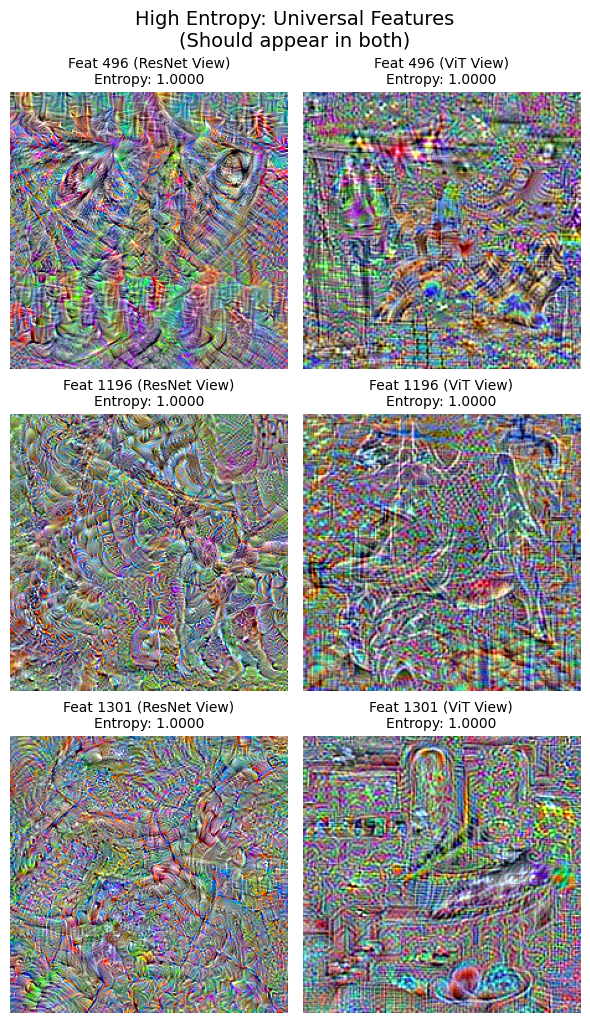

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

# ==========================================
# 1. OPTIMIZER WITH JITTER (The Fix)
# ==========================================
def random_jitter(img, shift=12):
    """
    Randomly shifts the image to force robust patterns.
    """
    padded = F.pad(img, (shift, shift, shift, shift), mode='reflect')
    h, w = img.shape[-2:]
    rx, ry = np.random.randint(0, 2*shift + 1, 2)
    return padded[:, :, ry:ry+h, rx:rx+w]

def optimize_feature_robust(model_idx, feature_idx, steps=250, lr=0.05, decay=1e-4):
    # Start with lower noise for cleaner results
    img = (torch.randn(1, 3, 224, 224) * 0.01).to(DEVICE).requires_grad_(True)

    # Adam usually converges faster for feature viz than SGD
    optimizer = optim.Adam([img], lr=lr, weight_decay=decay)

    for _ in range(steps):
        optimizer.zero_grad()

        # Apply Jitter BEFORE model
        jittered_img = random_jitter(img, shift=12)

        if model_idx == 0:
            model_A(jittered_img)
            act = activations['Model_A']
        else:
            model_B(jittered_img)
            act = activations['Model_B']

        z_pre = usae.encoders[model_idx](act - usae.b_pre[model_idx])
        loss = -z_pre[0, feature_idx]
        loss.backward()

        # Gradient Normalization
        if img.grad is not None:
            img.grad /= (torch.std(img.grad) + 1e-8)
        optimizer.step()

    return img.detach().cpu()

def robust_plot(tensor):
    img = tensor.squeeze().permute(1, 2, 0).numpy()
    vmin, vmax = np.percentile(img, 1), np.percentile(img, 99)
    img = np.clip(img, vmin, vmax)
    img = (img - vmin) / (vmax - vmin)
    return img

# ==========================================
# 2. VISUALIZATION EXECUTION
# ==========================================

# --- PREP INDICES ---
sorted_indices = np.argsort(entropy)

# High Entropy (Universal) -> Last 3 indices
high_indices = sorted_indices[-3:]

# Low Entropy (Model Specific) -> First 3 ACTIVE indices
# We filter for active neurons first, then take the lowest entropy ones
active_indices = np.where(active_mask)[0]
low_indices = sorted(active_indices, key=lambda x: entropy[x])[:3]

# --- PLOTTING FUNCTION ---
def plot_features(indices, title_main):
    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3.5 * len(indices)))
    plt.suptitle(title_main, fontsize=14, y=0.98)

    for i, idx in enumerate(indices):
        e_val = entropy[idx]

        # ResNet Optimization
        res_img = optimize_feature_robust(0, idx)
        axes[i, 0].imshow(robust_plot(res_img))
        axes[i, 0].set_title(f"Feat {idx} (ResNet View)\nEntropy: {e_val:.4f}", fontsize=10)
        axes[i, 0].axis('off')

        # ViT Optimization
        vit_img = optimize_feature_robust(1, idx)
        axes[i, 1].imshow(robust_plot(vit_img))
        axes[i, 1].set_title(f"Feat {idx} (ViT View)\nEntropy: {e_val:.4f}", fontsize=10)
        axes[i, 1].axis('off')

        # Optional: Add an arrow or label if one side is clearly blank
        # (This helps spot if it's truly model-specific)

    plt.tight_layout()
    plt.show()

# --- RUN PLOTS ---

print("Generating High Entropy (Universal) Visualizations...")
plot_features(high_indices, "High Entropy: Universal Features\n(Should appear in both)")

# print("Generating Low Entropy (Model-Specific) Visualizations...")
# plot_features(low_indices, "Low Entropy: Model-Specific Features\n(Should only appear clearly in one)")


=== OWNERSHIP VERIFICATION (Low Entropy) ===
Feature  | Entropy  | Owner    | ResNet %   | ViT %     
------------------------------------------------------------
1656     | 0.0000   | ViT      | 0.00%     | 100.00%
562      | 0.0000   | ViT      | 0.00%     | 100.00%
1352     | 0.0000   | ResNet   | 100.00%     | 0.00%


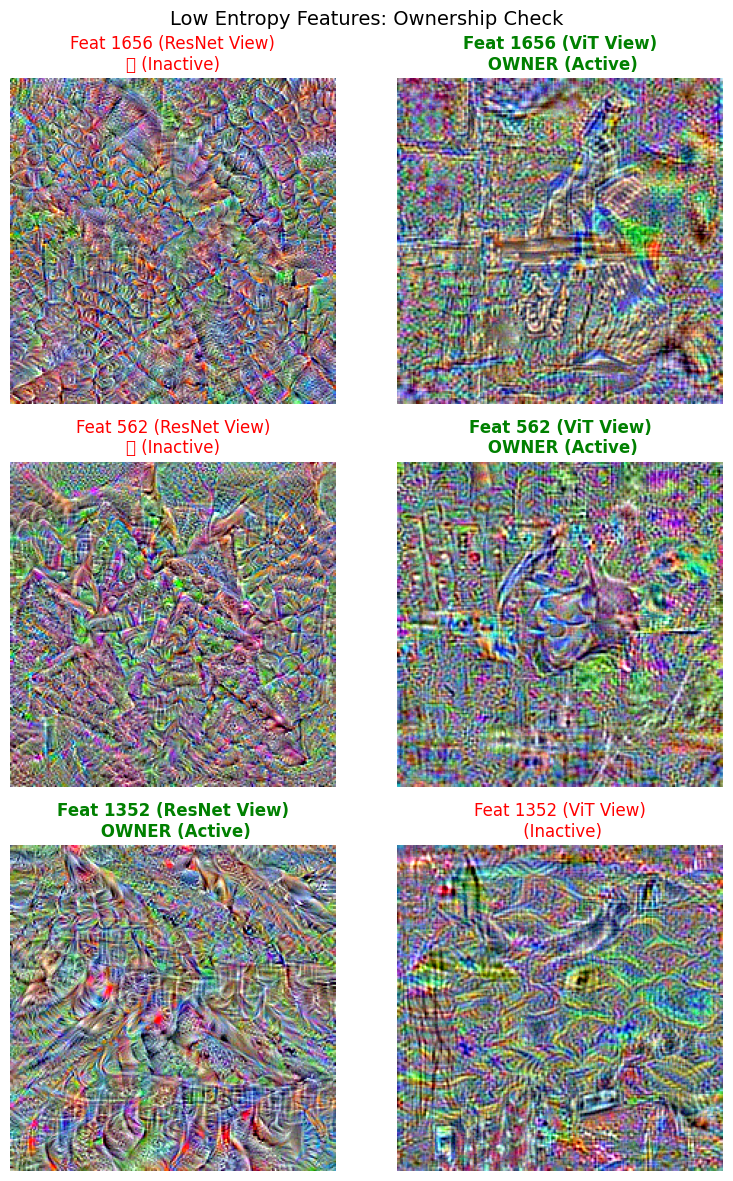

In [36]:

def random_jitter(img, shift=12):
    padded = F.pad(img, (shift, shift, shift, shift), mode='reflect')
    h, w = img.shape[-2:]
    rx, ry = np.random.randint(0, 2*shift + 1, 2)
    return padded[:, :, ry:ry+h, rx:rx+w]

def optimize_feature_robust(model_idx, feature_idx, steps=250, lr=0.05):
    img = (torch.randn(1, 3, 224, 224) * 0.01).to(DEVICE).requires_grad_(True)
    optimizer = optim.Adam([img], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        jittered_img = random_jitter(img, shift=12)

        if model_idx == 0:
            model_A(jittered_img); act = activations['Model_A']
        else:
            model_B(jittered_img); act = activations['Model_B']

        z_pre = usae.encoders[model_idx](act - usae.b_pre[model_idx])
        loss = -z_pre[0, feature_idx]
        loss.backward()
        if img.grad is not None: img.grad /= (torch.std(img.grad) + 1e-8)
        optimizer.step()

    return img.detach().cpu()

def robust_plot(tensor):
    img = tensor.squeeze().permute(1, 2, 0).numpy()
    vmin, vmax = np.percentile(img, 1), np.percentile(img, 99)
    img = np.clip(img, vmin, vmax)
    img = (img - vmin) / (vmax - vmin)
    return img

# ==========================================
# 2. SELECTION & VERIFICATION LOGIC
# ==========================================

# --- A. Select Low Entropy Features ---
active_indices = np.where(active_mask)[0]
low_indices = sorted(active_indices, key=lambda x: entropy[x])[:3]

print("\n=== OWNERSHIP VERIFICATION (Low Entropy) ===")
print(f"{'Feature':<8} | {'Entropy':<8} | {'Owner':<8} | {'ResNet %':<10} | {'ViT %':<10}")
print("-" * 60)

feature_meta = []

for idx in low_indices:

    tot = feat_acts_sum[idx].sum()
    p_a = (feat_acts_sum[idx, 0] / tot).item()
    p_b = (feat_acts_sum[idx, 1] / tot).item()

    # Determine Owner
    if p_a > p_b:
        owner = "ResNet"
        strength = p_a
    else:
        owner = "ViT"
        strength = p_b

    print(f"{idx:<8} | {entropy[idx]:.4f}   | {owner:<8} | {p_a:.2%}     | {p_b:.2%}")
    feature_meta.append({'idx': idx, 'owner': owner, 'score': strength})

# ==========================================
# 3. VISUALIZATION
# ==========================================

fig, axes = plt.subplots(len(low_indices), 2, figsize=(8, 4 * len(low_indices)))
plt.suptitle("Low Entropy Features: Ownership Check", fontsize=14, y=0.98)

for i, meta in enumerate(feature_meta):
    idx = meta['idx']
    owner = meta['owner']

    # --- Generate Images ---
    # We generate BOTH views to prove one fails
    img_resnet = optimize_feature_robust(0, idx)
    img_vit    = optimize_feature_robust(1, idx)

    # --- Plot ResNet View ---
    ax_res = axes[i, 0]
    ax_res.imshow(robust_plot(img_resnet))

    # Set Title Colors based on Ownership
    if owner == "ResNet":
        ax_res.set_title(f"Feat {idx} (ResNet View)\n OWNER (Active)", color='green', fontweight='bold')
        # Add a green border for emphasis (optional)
        for spine in ax_res.spines.values(): spine.set_edgecolor('green'); spine.set_linewidth(3)
    else:
        ax_res.set_title(f"Feat {idx} (ResNet View)\n❌ (Inactive)", color='red')
    ax_res.axis('off')

    # --- Plot ViT View ---
    ax_vit = axes[i, 1]
    ax_vit.imshow(robust_plot(img_vit))

    if owner == "ViT":
        ax_vit.set_title(f"Feat {idx} (ViT View)\n OWNER (Active)", color='green', fontweight='bold')
        for spine in ax_vit.spines.values(): spine.set_edgecolor('green'); spine.set_linewidth(3)
    else:
        ax_vit.set_title(f"Feat {idx} (ViT View)\n (Inactive)", color='red')
    ax_vit.axis('off')

plt.tight_layout()
plt.show()